In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)

In [2]:
df_train = pd.read_csv('train.csv', index_col='UniqueID')

print(df_train.head())


          disbursed_amount  asset_cost    ltv  branch_id  supplier_id  \
UniqueID                                                                
420825               50578       58400  89.55         67        22807   
537409               47145       65550  73.23         67        22807   
417566               53278       61360  89.63         67        22807   
624493               57513       66113  88.48         67        22807   
539055               52378       60300  88.39         67        22807   

          manufacturer_id  Current_pincode_ID Date.of.Birth Employment.Type  \
UniqueID                                                                      
420825                 45                1441      1/1/1984        Salaried   
537409                 45                1502      31-07-85   Self employed   
417566                 45                1497      24-08-85   Self employed   
624493                 45                1501      30-12-93   Self employed   
539055        

In [3]:
# Converting all column name to lower case and replacing space and dot with underscore
df_train.columns = df_train.columns.str.lower()
df_train.columns = df_train.columns.str.replace(' ', '_').str.replace('.', '_')
print(df_train.head())



          disbursed_amount  asset_cost    ltv  branch_id  supplier_id  \
UniqueID                                                                
420825               50578       58400  89.55         67        22807   
537409               47145       65550  73.23         67        22807   
417566               53278       61360  89.63         67        22807   
624493               57513       66113  88.48         67        22807   
539055               52378       60300  88.39         67        22807   

          manufacturer_id  current_pincode_id date_of_birth employment_type  \
UniqueID                                                                      
420825                 45                1441      1/1/1984        Salaried   
537409                 45                1502      31-07-85   Self employed   
417566                 45                1497      24-08-85   Self employed   
624493                 45                1501      30-12-93   Self employed   
539055        

In [4]:
## finding the columns that have null values 
f = df_train.isnull().sum()
print(f[f > 0])

employment_type    7661
dtype: int64


In [5]:
import numpy as np
import pandas as pd
import re

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --------------------------------------------------
# 1. Load data
# --------------------------------------------------
df = pd.read_csv("train.csv", index_col="UniqueID")

# --------------------------------------------------
# 2. Clean column names
# --------------------------------------------------
df.columns = (
    df.columns
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace(".", "_", regex=False)
)

# --------------------------------------------------
# 3. Fill missing employment_type with Unknown
# --------------------------------------------------
df["employment_type"] = df["employment_type"].fillna("Unknown")

# --------------------------------------------------
# 4. Convert date columns to datetime
# --------------------------------------------------
df["date_of_birth"] = pd.to_datetime(
    df["date_of_birth"],
    errors="coerce",
    dayfirst=True
)

df["disbursaldate"] = pd.to_datetime(
    df["disbursaldate"],
    errors="coerce",
    dayfirst=True
)

# --------------------------------------------------
# 5. Create age of customer at loan disbursal
# --------------------------------------------------
df["age"] = (
    (df["disbursaldate"] - df["date_of_birth"]).dt.days / 365.25
).round(1)

# --------------------------------------------------
# 6. Convert average_acct_age into months
# Example: "1yrs 11mon" -> 23
# --------------------------------------------------
avg_age_parts = df["average_acct_age"].astype(str).str.extract(
    r"(\d+)yrs\s*(\d+)mon"
)

df["average_acct_age_months"] = (
    avg_age_parts[0].astype(float) * 12 + avg_age_parts[1].astype(float)
)

# --------------------------------------------------
# 7. Convert credit_history_length into months
# Example: "2yrs 3mon" -> 27
# --------------------------------------------------
credit_hist_parts = df["credit_history_length"].astype(str).str.extract(
    r"(\d+)yrs\s*(\d+)mon"
)

df["credit_history_length_months"] = (
    credit_hist_parts[0].astype(float) * 12 + credit_hist_parts[1].astype(float)
)

# --------------------------------------------------
# 8. Credit-risk feature engineering
# --------------------------------------------------
df["no_bureau_history"] = (df["perform_cns_score"] == 0).astype(int)

df["has_overdue_account"] = (
    df["pri_overdue_accts"] > 0
).astype(int)

df["recent_delinquency_flag"] = (
    df["delinquent_accts_in_last_six_months"] > 0
).astype(int)

df["high_inquiry_flag"] = (
    df["no_of_inquiries"] >= 3
).astype(int)

df["active_account_ratio"] = (
    df["pri_active_accts"] / df["pri_no_of_accts"]
).replace([np.inf, -np.inf], np.nan)

df["overdue_account_ratio"] = (
    df["pri_overdue_accts"] / df["pri_no_of_accts"]
).replace([np.inf, -np.inf], np.nan)

df["primary_utilization"] = (
    df["pri_current_balance"] / df["pri_sanctioned_amount"]
).replace([np.inf, -np.inf], np.nan)

# --------------------------------------------------
# 9. Drop unnecessary columns
# --------------------------------------------------
drop_cols = [
    "branch_id",
    "supplier_id",
    "manufacturer_id",
    "manufacture_id",
    "current_pincode_id",
    "employee_code_id",
    "perform_cns_score_description",
    "date_of_birth",
    "disbursaldate",
    "average_acct_age",
    "credit_history_length"
]

df = df.drop(columns=drop_cols, errors="ignore")

# --------------------------------------------------
# 10. Split into X and y
# --------------------------------------------------
X = df.drop(columns=["loan_default"])
y = df["loan_default"]

# --------------------------------------------------
# 11. Train-test split
# This is your own validation/test split from train.csv
# --------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# --------------------------------------------------
# 12. Encode employment_type after split
# --------------------------------------------------
X_train = pd.get_dummies(
    X_train,
    columns=["employment_type"],
    drop_first=True,
    dtype=int
)

X_test = pd.get_dummies(
    X_test,
    columns=["employment_type"],
    drop_first=True,
    dtype=int
)

# Make sure test has the same columns as train
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# --------------------------------------------------
# 13. Log-transform amount columns
# --------------------------------------------------
amount_cols = [
    "disbursed_amount",
    "asset_cost",
    "pri_current_balance",
    "pri_sanctioned_amount",
    "pri_disbursed_amount",
    "primary_instal_amt"
]

# Keep only columns that actually exist
amount_cols = [col for col in amount_cols if col in X_train.columns]

for col in amount_cols:
    X_train[col] = np.sign(X_train[col]) * np.log1p(np.abs(X_train[col]))
    X_test[col] = np.sign(X_test[col]) * np.log1p(np.abs(X_test[col]))

# --------------------------------------------------
# 14. Fill missing numeric values
# Use train medians for both train and test
# --------------------------------------------------
numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns

train_medians = X_train[numeric_cols].median()

X_train[numeric_cols] = X_train[numeric_cols].fillna(train_medians)
X_test[numeric_cols] = X_test[numeric_cols].fillna(train_medians)

# --------------------------------------------------
# 15. Standardize selected amount columns
# Fit scaler on train, transform train and test
# --------------------------------------------------
scaler = StandardScaler()

X_train[amount_cols] = scaler.fit_transform(X_train[amount_cols])
X_test[amount_cols] = scaler.transform(X_test[amount_cols])

# --------------------------------------------------
# 16. Final checks
# --------------------------------------------------
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("Train missing values:", X_train.isna().sum().sum())
print("Test missing values:", X_test.isna().sum().sum())

print("Train default rate:")
print(y_train.value_counts(normalize=True))

print("Test default rate:")
print(y_test.value_counts(normalize=True))

X_train shape: (186523, 40)
X_test shape: (46631, 40)
Train missing values: 0
Test missing values: 0
Train default rate:
loan_default
0    0.782928
1    0.217072
Name: proportion, dtype: float64
Test default rate:
loan_default
0    0.782934
1    0.217066
Name: proportion, dtype: float64


In [6]:
# --------------------------------------------------
# Logistic Regression: Class Weight vs SMOTE
# --------------------------------------------------

import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)
#!pip install imbalanced-learn
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline


# --------------------------------------------------
# 1. Define C values for Grid Search
# Smaller C = stronger regularization
# Larger C = weaker regularization
# --------------------------------------------------

param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100]
}


# --------------------------------------------------
# 2. Model 1: Logistic Regression with class_weight
# Solver is left as default
# --------------------------------------------------

class_weight_pipeline = Pipeline(steps=[
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    ))
])

class_weight_grid = GridSearchCV(
    estimator=class_weight_pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

class_weight_grid.fit(X_train, y_train)

"""
# --------------------------------------------------
# 3. Model 2: Logistic Regression with SMOTE
# SMOTE is applied only to training folds inside GridSearchCV
# Solver is left as default
# --------------------------------------------------

smote_pipeline = Pipeline(steps=[
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

smote_grid = GridSearchCV(
    estimator=smote_pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

smote_grid.fit(X_train, y_train)"""


# --------------------------------------------------
# 4. Get best models
# --------------------------------------------------

best_class_weight_model = class_weight_grid.best_estimator_
"""best_smote_model = smote_grid.best_estimator_"""

print("Best C for Class Weight model:", class_weight_grid.best_params_)
print("Best CV ROC-AUC for Class Weight model:", class_weight_grid.best_score_)
"""
print("\nBest C for SMOTE model:", smote_grid.best_params_)
print("Best CV ROC-AUC for SMOTE model:", smote_grid.best_score_)"""


# --------------------------------------------------
# 5. Evaluate both models on test/validation data
# --------------------------------------------------

models = {
    "Class Weight Logistic Regression": best_class_weight_model,
   #
}

results = []

for name, model in models.items():
    
    # Predict class labels
    y_pred = model.predict(X_test)
    
    # Predict probabilities for ROC-AUC
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # Store metrics
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })
    
    print("\n" + "="*60)
    print(name)
    print("="*60)
    
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))


# --------------------------------------------------
# 6. Compare results
# --------------------------------------------------

results_df = pd.DataFrame(results)

print("\nFinal Model Comparison:")
print(results_df)


# --------------------------------------------------
# 7. Select better model based on ROC-AUC
# For PD modeling, ROC-AUC is usually the main ranking metric
# --------------------------------------------------

best_model_name = results_df.sort_values("ROC-AUC", ascending=False).iloc[0]["Model"]

print("\nBetter model based on ROC-AUC:")
print(best_model_name)

Best C for Class Weight model: {'model__C': 10}
Best CV ROC-AUC for Class Weight model: 0.5935442033186096

Class Weight Logistic Regression
Confusion Matrix:
[[18381 18128]
 [ 3777  6345]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.50      0.63     36509
           1       0.26      0.63      0.37     10122

    accuracy                           0.53     46631
   macro avg       0.54      0.57      0.50     46631
weighted avg       0.71      0.53      0.57     46631


Final Model Comparison:
                              Model  Accuracy  Precision    Recall  F1 Score  \
0  Class Weight Logistic Regression  0.530248   0.259265  0.626852  0.366816   

    ROC-AUC  
0  0.588268  

Better model based on ROC-AUC:
Class Weight Logistic Regression


c:\Users\muhil\anaconda3\envs\FSFMPython\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [8]:
import numpy as np
import pandas as pd
 
# 1. Select final PD model
pd_model = best_class_weight_model
 
# 2. Create IFRS 9 output dataframe for validation/test split
ifrs9_df = pd.DataFrame(index=X_test.index)
ifrs9_df["actual_default"] = y_test
 
# 3. Predict 12-month PD using the logistic regression model
ifrs9_df["PD_12M"] = pd_model.predict_proba(X_test)[:, 1]
 
# 4. Bring back original/raw validation rows
raw_test = df.loc[X_test.index].copy()
 
# 5. Create EAD using disbursed amount as proxy
ifrs9_df["EAD"] = raw_test["disbursed_amount"]
ifrs9_df["EAD"] = pd.to_numeric(ifrs9_df["EAD"], errors="coerce")
ifrs9_df["EAD"] = ifrs9_df["EAD"].fillna(ifrs9_df["EAD"].median())
ifrs9_df["EAD"] = ifrs9_df["EAD"].clip(lower=0)
 
# 6. Create LGD assumption
ifrs9_df["LGD"] = 0.40
 
# 7. Assign IFRS 9 stages
stage2_pd_threshold = 0.20
ifrs9_df["stage"] = "Stage 1"
 
ifrs9_df.loc[
    (ifrs9_df["PD_12M"] >= stage2_pd_threshold) |
    (raw_test["has_overdue_account"] == 1) |
    (raw_test["recent_delinquency_flag"] == 1),
    "stage"
] = "Stage 2"
 
ifrs9_df.loc[
    ifrs9_df["actual_default"] == 1,
    "stage"
] = "Stage 3"
 
# 8. Approximate lifetime PD
remaining_life_years = 3
ifrs9_df["PD_lifetime"] = 1 - (1 - ifrs9_df["PD_12M"]) ** remaining_life_years
ifrs9_df["PD_lifetime"] = ifrs9_df["PD_lifetime"].clip(upper=1)
 
# 9. Select final IFRS 9 PD depending on stage
ifrs9_df["IFRS9_PD"] = ifrs9_df["PD_12M"]
 
ifrs9_df.loc[
    ifrs9_df["stage"] == "Stage 2",
    "IFRS9_PD"
] = ifrs9_df["PD_lifetime"]
 
ifrs9_df.loc[
    ifrs9_df["stage"] == "Stage 3",
    "IFRS9_PD"
] = 1.0
 
# 10. Calculate Expected Credit Loss
ifrs9_df["ECL"] = ifrs9_df["IFRS9_PD"] * ifrs9_df["LGD"] * ifrs9_df["EAD"]
 
# 11. Stage-level summary
stage_summary = ifrs9_df.groupby("stage").agg(
    number_of_loans=("ECL", "count"),
    total_EAD=("EAD", "sum"),
    average_12M_PD=("PD_12M", "mean"),
    average_IFRS9_PD=("IFRS9_PD", "mean"),
    average_LGD=("LGD", "mean"),
    total_ECL=("ECL", "sum"),
    actual_default_rate=("actual_default", "mean")
)
 
stage_summary = stage_summary.round(4)
print("IFRS 9 Stage Summary:")
print(stage_summary)
 
# 12. Total portfolio summary
total_loans = len(ifrs9_df)
total_ead = ifrs9_df["EAD"].sum()
total_ecl = ifrs9_df["ECL"].sum()
average_pd = ifrs9_df["IFRS9_PD"].mean()
average_lgd = ifrs9_df["LGD"].mean()
 
print("\nPortfolio Summary")
print("-----------------")
print("Total loans:", total_loans)
print("Total EAD:", round(total_ead, 2))
print("Total ECL:", round(total_ecl, 2))
print("Average IFRS9 PD:", round(average_pd, 4))
print("Average LGD:", round(average_lgd, 4))
 
# 13. View final output
ifrs9_df.head()


IFRS 9 Stage Summary:
         number_of_loans   total_EAD  average_12M_PD  average_IFRS9_PD  \
stage                                                                    
Stage 1               51     1823054          0.1700            0.1700   
Stage 2            36458  1962283210          0.4924            0.8593   
Stage 3            10122   567828295          0.5159            1.0000   

         average_LGD     total_ECL  actual_default_rate  
stage                                                    
Stage 1          0.4  1.243940e+05                  0.0  
Stage 2          0.4  6.788198e+08                  0.0  
Stage 3          0.4  2.271313e+08                  1.0  

Portfolio Summary
-----------------
Total loans: 46631
Total EAD: 2531934559
Total ECL: 906075485.37
Average IFRS9 PD: 0.8891
Average LGD: 0.4


,actual_default,PD_12M,EAD,LGD,stage,PD_lifetime,IFRS9_PD,ECL
UniqueID,,,,,,,,
620864,0,0.519277,49538,0.4,Stage 2,0.888908,0.888908,17613.882933
587754,0,0.416441,67882,0.4,Stage 2,0.801274,0.801274,21756.840750
431987,1,0.404789,65789,0.4,Stage 3,0.789131,1.000000,26315.600000
465449,0,0.471796,48303,0.4,Stage 2,0.852631,0.852631,16473.860459
547508,0,0.454688,60713,0.4,Stage 2,0.837843,0.837843,20347.191970


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# Monte Carlo Economic Capital Simulation
# --------------------------------------------------
# Purpose:
# Simulate many possible future portfolio losses.
#
# In each simulation:
# 1. Generate a random number between 0 and 1 for each borrower.
# 2. If random number < borrower PD, borrower defaults.
# 3. If borrower defaults, loss = LGD × EAD.
# 4. Sum losses across all borrowers.
# 5. Repeat this many times to get a loss distribution.
# --------------------------------------------------


# --------------------------------------------------
# 1. Copy portfolio data
# --------------------------------------------------

portfolio = ifrs9_df.copy()


# --------------------------------------------------
# 2. Set scenario assumptions
# --------------------------------------------------
# Base scenario:
# PD multiplier = 1.0 means no stress adjustment.
# LGD = 40% means we assume 40% loss if default happens.

scenario_name = "Base Scenario"
pd_multiplier = 1.0
lgd_assumption = 0.40


# --------------------------------------------------
# 3. Create adjusted PD
# --------------------------------------------------
# We use PD_12M because economic capital usually uses a 1-year horizon.
# Adjusted PD = model PD × scenario multiplier.
#
# Example:
# If model PD = 10%
# and pd_multiplier = 1.5
# then adjusted PD = 15%

portfolio["adjusted_PD"] = portfolio["PD_12M"] * pd_multiplier

# PD cannot be below 0 or above 1.
portfolio["adjusted_PD"] = portfolio["adjusted_PD"].clip(0, 1)


# --------------------------------------------------
# 4. Set LGD and EAD
# --------------------------------------------------
# EAD = exposure amount
# LGD = percentage loss if default happens

portfolio["capital_LGD"] = lgd_assumption

PD = portfolio["adjusted_PD"].values
LGD = portfolio["capital_LGD"].values
EAD = portfolio["EAD"].values


# --------------------------------------------------
# 5. Calculate loss amount if each borrower defaults
# --------------------------------------------------
# If a borrower defaults:
# loss = LGD × EAD
#
# Example:
# EAD = 100,000
# LGD = 40%
# Loss if default = 40,000

loss_if_default = LGD * EAD


# --------------------------------------------------
# 6. Set Monte Carlo settings
# --------------------------------------------------

n_simulations = 10000
confidence_level = 0.99

# Seed makes results reproducible.
# This means you get the same random results each time you run the code.
np.random.seed(42)


# --------------------------------------------------
# 7. Run Monte Carlo simulation
# --------------------------------------------------
# We store total portfolio loss from each simulation.

simulated_losses = []

for i in range(n_simulations):
    
    # Generate one random number between 0 and 1 for each borrower.
    random_numbers = np.random.rand(len(portfolio))
    
    # Borrower defaults if random number is less than adjusted PD.
    #
    # Example:
    # PD = 0.20
    # random number = 0.13
    # 0.13 < 0.20, so borrower defaults.
    defaults = random_numbers < PD
    
    # Calculate loss for every borrower.
    # If default = True, loss = LGD × EAD.
    # If default = False, loss = 0.
    losses = defaults * loss_if_default
    
    # Sum all borrower losses to get total portfolio loss.
    total_portfolio_loss = losses.sum()
    
    # Store the loss from this simulation.
    simulated_losses.append(total_portfolio_loss)


# Convert list to numpy array for calculations.
simulated_losses = np.array(simulated_losses)


# --------------------------------------------------
# 8. Calculate Expected Loss
# --------------------------------------------------
# Monte Carlo Expected Loss = average of simulated losses.

expected_loss_mc = simulated_losses.mean()

# Formula Expected Loss = sum(PD × LGD × EAD)
expected_loss_formula = np.sum(PD * LGD * EAD)


# --------------------------------------------------
# 9. Calculate VaR
# --------------------------------------------------
# VaR at 99% means:
# 99% of simulated losses are below this number.
# 1% of simulated losses are worse than this number.

var_99 = np.percentile(simulated_losses, confidence_level * 100)


# --------------------------------------------------
# 10. Calculate Economic Capital
# --------------------------------------------------
# Economic Capital = VaR - Expected Loss
#
# This is the unexpected loss buffer.

economic_capital = var_99 - expected_loss_mc


# --------------------------------------------------
# 11. Print results
# --------------------------------------------------

print("Monte Carlo Economic Capital Results")
print("------------------------------------")
print("Scenario:", scenario_name)
print("Number of simulations:", n_simulations)
print("Confidence level:", confidence_level)
print("Expected Loss from Monte Carlo:", round(expected_loss_mc, 2))
print("Expected Loss from Formula:", round(expected_loss_formula, 2))
print("VaR 99%:", round(var_99, 2))
print("Economic Capital:", round(economic_capital, 2))

Monte Carlo Economic Capital Results
------------------------------------
Scenario: Base Scenario
Number of simulations: 10000
Confidence level: 0.99
Expected Loss from Monte Carlo: 509515732.13
Expected Loss from Formula: 509519183.66
VaR 99%: 515081688.48
Economic Capital: 5565956.35


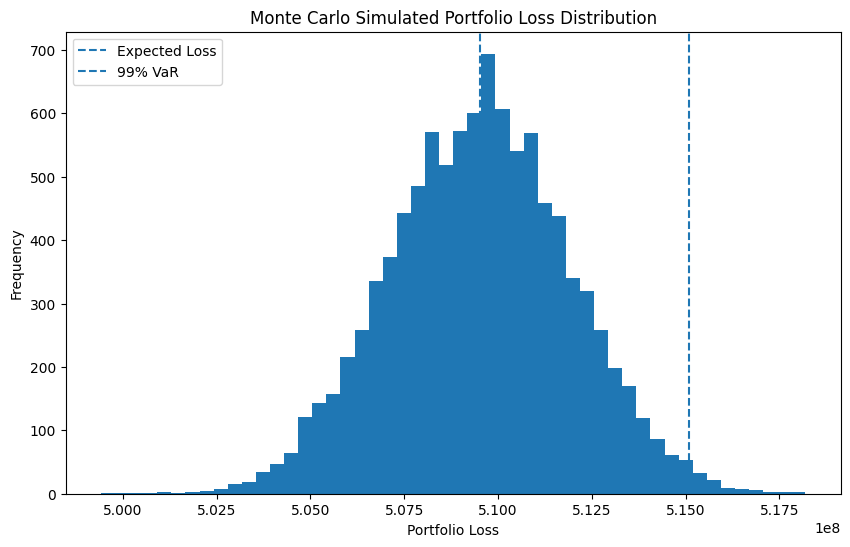

In [10]:
# --------------------------------------------------
# Plot simulated portfolio loss distribution
# --------------------------------------------------

plt.figure(figsize=(10, 6))

# Histogram shows how often different portfolio loss amounts occurred.
plt.hist(simulated_losses, bins=50)

# Expected Loss line
plt.axvline(
    expected_loss_mc,
    linestyle="--",
    label="Expected Loss"
)

# VaR line
plt.axvline(
    var_99,
    linestyle="--",
    label="99% VaR"
)

plt.title("Monte Carlo Simulated Portfolio Loss Distribution")
plt.xlabel("Portfolio Loss")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [11]:
economic_capital_summary = pd.DataFrame({
    "Metric": [
        "Scenario",
        "Number of Simulations",
        "Expected Loss - Monte Carlo",
        "Expected Loss - Formula",
        "VaR 99%",
        "Economic Capital"
    ],
    "Value": [
        scenario_name,
        n_simulations,
        round(expected_loss_mc, 2),
        round(expected_loss_formula, 2),
        round(var_99, 2),
        round(economic_capital, 2)
    ]
})

economic_capital_summary

,Metric,Value
0,Scenario,Base Scenario
1,Number of Simulations,10000
2,Expected Loss - Monte Carlo,509515732.13
3,Expected Loss - Formula,509519183.66
4,VaR 99%,515081688.48
5,Economic Capital,5565956.35
